In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler

In [84]:
cols = ["fLength","fWidth","fSize","fConc","fConc1","fAsym","fM3Long","fM3Trans","fAlpha","fDist","class"]
df = pd.read_csv("magic04.data", names = cols )
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [85]:
df['class'] = (df['class'] == 'g').astype(int)

In [86]:
print(df["class"].value_counts())


class
1    12332
0     6688
Name: count, dtype: int64


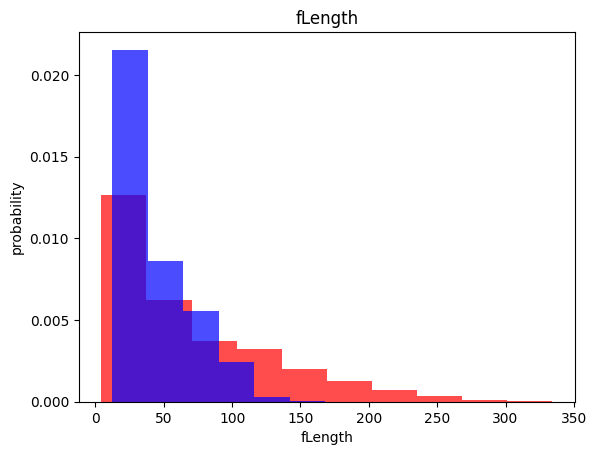

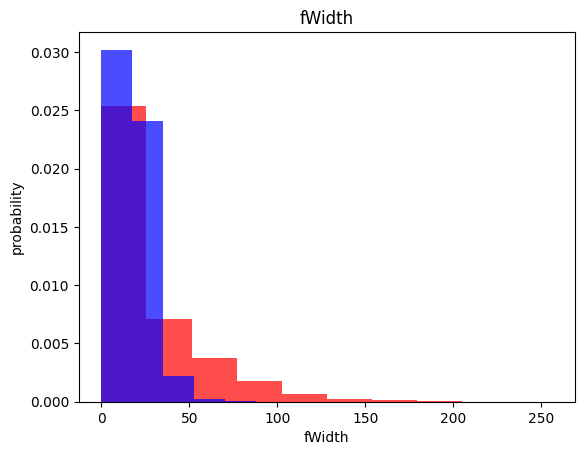

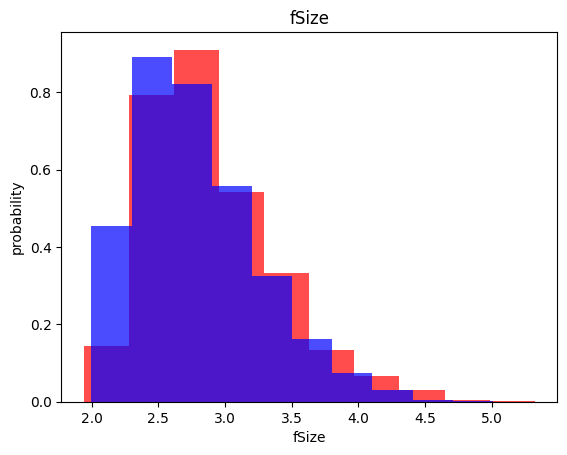

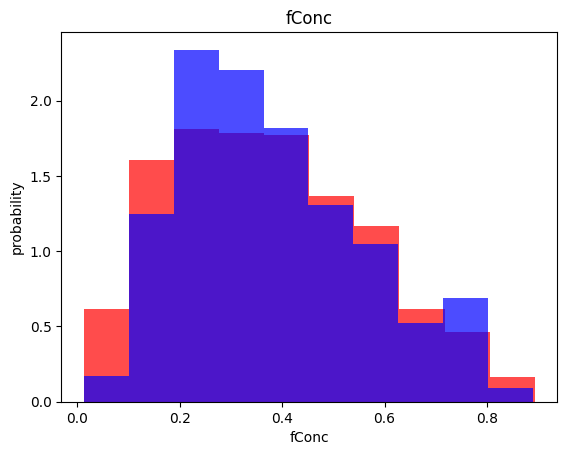

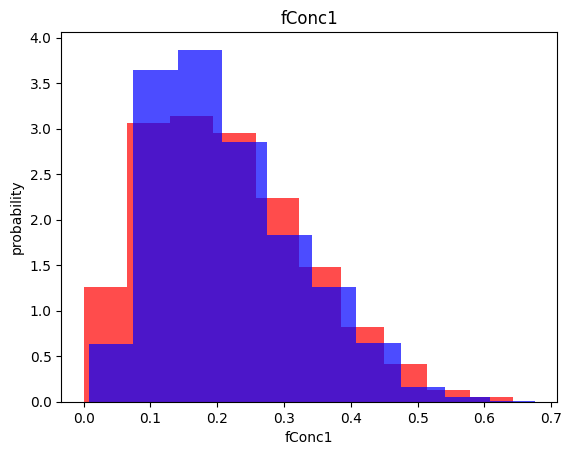

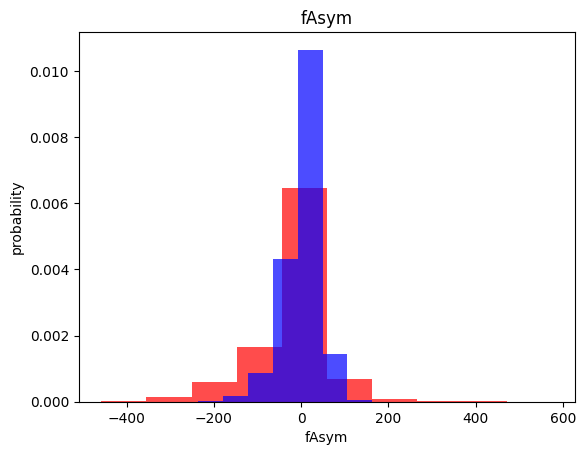

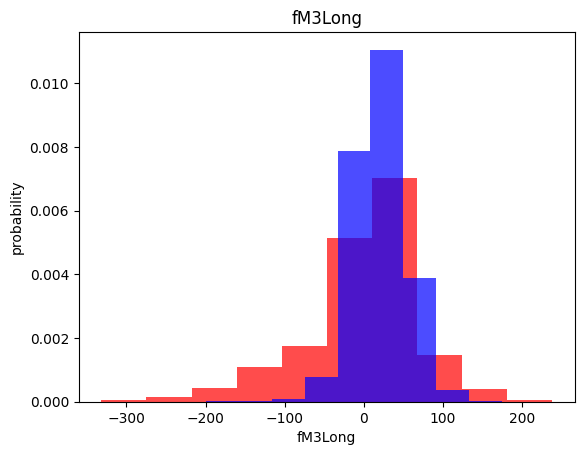

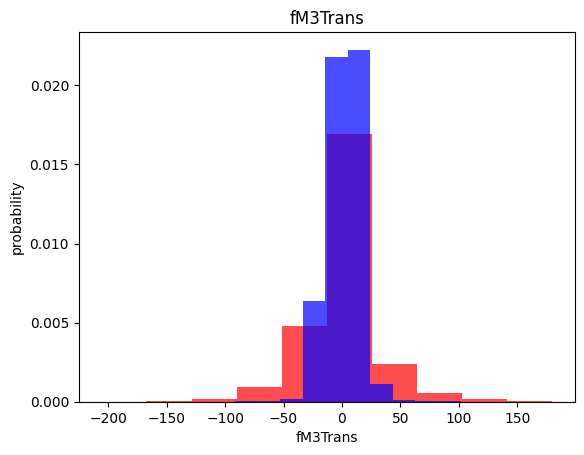

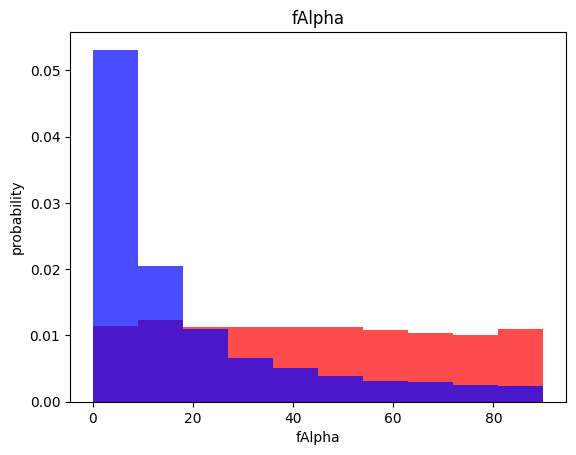

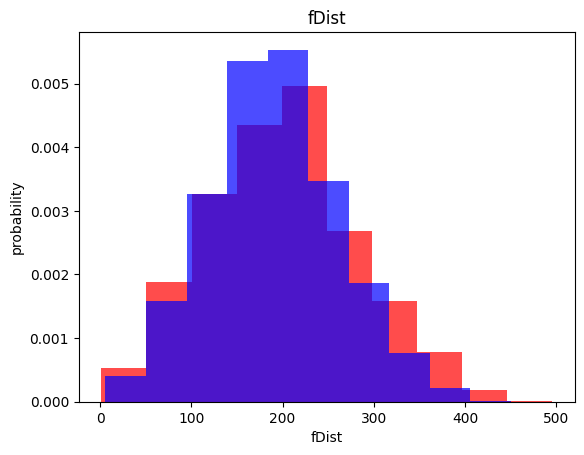

In [87]:
for label in cols[:-1]:
    plt.hist(df[df['class'] == 0][label], color = 'red' , alpha = 0.7 , density = True)
    plt.hist(df[df['class'] == 1][label], color = 'blue', alpha = 0.7 , density = True)
    plt.title(label)
    plt.xlabel(label)
    plt.ylabel("probability")
    plt.show()
    

In [101]:
train , valid , test = np.split(df.sample(frac = 1) , [ int(len(df)*0.6) , int(len(df)*0.8) ])

c:\Users\ramis\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [102]:
def scale_dataset(data_frame , oversample = False):
    X = data_frame[data_frame.columns[:-1]].values
    Y = data_frame[data_frame.columns[-1]].values
    
    scaler = StandardScaler()
    
    X = scaler.fit_transform(X)
    
    if oversample :
        ros = RandomOverSampler()
        X , Y = ros.fit_resample(X,Y)
        
    
    data = np.hstack((X, np.reshape(Y, (-1, 1))))

    return data, X, Y     
    
    

In [103]:
train, X_train, y_train = scale_dataset(train, oversample=True)
valid, X_valid, y_valid = scale_dataset(valid, oversample=False)
test, X_test, y_test = scale_dataset(test, oversample=False)